# DrugEx ROCS RNN Tutorial

## Overview
Comprehensive end-to-end workflow for ROCS-based molecular generation using DrugEx, mirroring the Sequence-RNN tutorial with ROCS scoring objectives.

## Workflow
1. **Transfer Learning**: Fine-tune pretrained RNN on CCR dataset
2. **Reinforcement Learning**: Train models across multiple conformer/scorer backends:
   - OpenEye (Omega conformers + ROCS CLI)
   - RDKit (aggregate + supermolecule/consensus)
   - CDPKit (aggregate + supermolecule/consensus)
3. **Sampling & Evaluation**: Generate molecules and cross-validate across backends

## Key Components
- **Conformer Generators**: Omega, RDKit, CDPKit
- **ROCS Scorers**: CLI-based, RDKit-based, CDPKit-based variants
- **Evaluation Metrics**: Shape/color similarity, scaffold analysis, novelty assessment
- **Cross-Backend Validation**: Native scoring comparison across all backends

## Prerequisites
- Python 3.10 with DrugEx
- RDKit (required)
- OpenEye toolkits + ROCS CLI (optional)
- CDPKit libraries (optional)
- CCR dataset and ROCS query files

## Output
Trained RL agents for each backend combination with comprehensive evaluation of generated molecule sets including scaffold diversity, novelty metrics, and cross-backend scoring consistency.

## Environment Setup

In [1]:
from __future__ import annotations

import os
import shutil
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Callable, Dict, Iterable, List, Optional

import numpy as np
import torch
import pandas as pd
from IPython.display import display, HTML
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem

from drugex.training.generators.sequence_rnn import SequenceRNN
from drugex.training.scorers.conformer_generators import (
    OmegaConformerGenerator,
    RDKitConformerGenerator,
    CDPKitConformerGenerator,
    OE_AVAILABLE as OMEGA_AVAILABLE,
    CDPL_AVAILABLE as CDPKIT_AVAILABLE,
)
from drugex.training.scorers.cli_rocs import CLIROCSScorer, OE_AVAILABLE as ROCS_AVAILABLE
from drugex.training.scorers.rdkit_rocs import (
    RDKitAggregateScorer,
    RDKitSupermoleculeScorer,
)
from drugex.training.scorers.cdpkit_rocs import (
    CDPKitROCSAggregateScorer,
    CDPKitROCSSupermoleculeScorer,
)
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.scorers.properties import Property
from drugex.training.environment import DrugExEnvironment
from drugex.training.explorers.sequence_explorer import SequenceExplorer
from drugex.training.monitors import FileMonitor
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.data.corpus.vocabulary import VocSmiles
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter
from drugex.data.datasets import SmilesDataSet
from drugex.logs import logger

NOTEBOOK_NAME = "DrugEx_ROCS_RNN_Showcase.ipynb"


def locate_notebook_dir() -> Path:
    """Resolve the directory containing this notebook independent of CWD."""
    candidates: List[Path] = []
    try:
        nb_path = Path(__file__).resolve()
        candidates.append(nb_path.parent)
    except NameError:
        pass

    cwd = Path.cwd().resolve()
    candidates.append(cwd)

    env_dir = os.environ.get("DRUGEX_NOTEBOOK_DIR")
    if env_dir:
        candidates.append(Path(env_dir).expanduser())

    candidates.append(cwd / "tutorial" / "rocs")

    for candidate in candidates:
        try:
            candidate = candidate.resolve()
        except Exception:
            continue
        if (candidate / NOTEBOOK_NAME).exists():
            return candidate

    for parent in cwd.parents:
        candidate = (parent / "tutorial" / "rocs").resolve()
        if (candidate / NOTEBOOK_NAME).exists():
            return candidate

    return cwd


NOTEBOOK_DIR = locate_notebook_dir()


def locate_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    return start


REPO_ROOT = locate_repo_root(NOTEBOOK_DIR)
DATA_ROOT = NOTEBOOK_DIR / "rocs_rl_ccr"
RESOURCES_DIR = DATA_ROOT / "rdkit_cdpkit"

CCR_DATA_PATH = RESOURCES_DIR / "CCR_HUMAN_AL.tsv"

RDKit_REF_SDF = RESOURCES_DIR / "CCR2_reference_ligands.sdf"
ROCS_QUERY = RDKit_REF_SDF
SUPER_SDF = RESOURCES_DIR / "supermol_123.sdf"

PRETRAINED_DIRS = [
    REPO_ROOT / "tutorial" / "data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT",
    REPO_ROOT / "data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT",
    NOTEBOOK_DIR / "../data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT",
]
PRETRAINED_VOCAB = "Papyrus05.5_smiles_rnn_PT.vocab"
PRETRAINED_PKG = "Papyrus05.5_smiles_rnn_PT.pkg"

FINETUNE_DIR = DATA_ROOT / "finetune_runs"
FINETUNE_CHECKPOINT = DATA_ROOT / "finetune.pkg"
FINETUNE_VOCAB = DATA_ROOT / "finetune.vocab"

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Repository root: {REPO_ROOT}")
print(f"Data root: {DATA_ROOT}")

Notebook directory: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs
Repository root: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS
Data root: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr


## Resource Checklist

In [2]:
resources = [
    ("Omega toolkit", OMEGA_AVAILABLE, None),
    ("ROCS CLI", shutil.which("rocs") is not None, shutil.which("rocs")),
    ("CDPKit (CDPL)", CDPKIT_AVAILABLE, None),
    ("CCR dataset", CCR_DATA_PATH.exists(), CCR_DATA_PATH),
    ("ROCS query", ROCS_QUERY.exists(), ROCS_QUERY),
    ("RDKit reference SDF", RDKit_REF_SDF.exists(), RDKit_REF_SDF),
    ("Supermolecule SDF", SUPER_SDF.exists(), SUPER_SDF),
    ("Finetune checkpoint", FINETUNE_CHECKPOINT.exists(), FINETUNE_CHECKPOINT),
    ("Finetune vocab", FINETUNE_VOCAB.exists(), FINETUNE_VOCAB),
]

resource_df = pd.DataFrame(
    [
        {
            "resource": name,
            "available": bool(flag),
            "path": str(path) if path else "",
        }
        for name, flag, path in resources
    ]
)
resource_df



,resource,available,path
0,Omega toolkit,True,
1,ROCS CLI,True,/home/dodo/bin/rocs
2,CDPKit (CDPL),True,
3,CCR dataset,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
4,ROCS query,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
5,RDKit reference SDF,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
6,Supermolecule SDF,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
7,Finetune checkpoint,True,/home/dodo/Documents/projects/drugex-rocs/Drug...
8,Finetune vocab,True,/home/dodo/Documents/projects/drugex-rocs/Drug...


## Data Preparation

In [3]:
if not CCR_DATA_PATH.exists():
    raise FileNotFoundError(f"CCR dataset missing: {CCR_DATA_PATH}")

ccr_df = pd.read_csv(CCR_DATA_PATH, sep="	").dropna(subset=["SMILES"])
SAMPLE_SIZE = 128
candidate_smiles = ccr_df["SMILES"].head(SAMPLE_SIZE).tolist()


def embed_reference(mol: Chem.Mol) -> Optional[Chem.Mol]:
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    status = AllChem.EmbedMolecule(mol, randomSeed=0xF00D)
    if status != 0:
        return None
    AllChem.UFFOptimizeMolecule(mol)
    return mol


@lru_cache(maxsize=1)
def load_rdkit_references() -> List[Chem.Mol]:
    refs: List[Chem.Mol] = []
    if not RDKit_REF_SDF.exists():
        return refs
    suppl = Chem.SDMolSupplier(str(RDKit_REF_SDF), removeHs=False)
    for mol in suppl:
        if mol is None:
            continue
        if mol.GetNumConformers() == 0:
            mol = embed_reference(mol)
        if mol is not None and mol.GetNumConformers() > 0:
            refs.append(mol)
    return refs


RDKit_REFERENCE_MOLS = load_rdkit_references()
print(f"Loaded {len(candidate_smiles)} candidate SMILES")
print(f"RDKit reference molecules available: {len(RDKit_REFERENCE_MOLS)}")

Loaded 128 candidate SMILES
RDKit reference molecules available: 5


In [4]:
RUN_TRANSFER = True
TRANSFER_CONFIG = {
    "epochs": 120,
    "train_split": 0.9,
    "chunk_size": 500,
    "batch_size": 256,
    "max_valid_size": 1000,
    "shuffle": True,
    "n_proc": 25,
}


def find_pretrained_dir() -> Path:
    for candidate in PRETRAINED_DIRS:
        vocab = candidate / PRETRAINED_VOCAB
        pkg = candidate / PRETRAINED_PKG
        if vocab.exists() and pkg.exists():
            return candidate
    raise FileNotFoundError("Papyrus pretrained checkpoint not found in configured locations")


@lru_cache(maxsize=1)
def load_vocabulary(update=False) -> VocSmiles:
    if FINETUNE_VOCAB.exists():
        return VocSmiles.fromFile(str(FINETUNE_VOCAB), encode_frags=False, max_len=100, min_len=10)
    pretrained_dir = find_pretrained_dir()
    return VocSmiles.fromFile(str(pretrained_dir / PRETRAINED_VOCAB), encode_frags=False, max_len=100, min_len=10)


def prepare_finetune_loaders(config: Dict) -> tuple:
    voc = load_vocabulary()
    smiles_all = ccr_df["SMILES"].dropna().tolist()
    splitter = RandomTrainTestSplitter(1.0 - config["train_split"], config["max_valid_size"], shuffle=config["shuffle"])
    smiles_train, smiles_valid = splitter(smiles_all)

    data_dir = DATA_ROOT / "encoded_rnn"
    data_dir.mkdir(parents=True, exist_ok=True)

    encoder = CorpusEncoder(
        SequenceCorpus,
        {
            "vocabulary": voc,
            "update_voc": False,
            "throw": True,
        },
        n_proc=config["n_proc"],
        chunk_size=config["chunk_size"],
    )

    train_collector = SmilesDataSet(data_dir / "ccr_train.tsv", rewrite=True)
    valid_collector = SmilesDataSet(data_dir / "ccr_valid.tsv", rewrite=True)

    encoder.apply(smiles_train, collector=train_collector)
    encoder.apply(smiles_valid, collector=valid_collector)

    train_loader = train_collector.asDataLoader(batch_size=config["batch_size"])
    valid_loader = valid_collector.asDataLoader(batch_size=config["batch_size"])
    return voc, train_loader, valid_loader


def run_transfer_learning(config: Dict, execute: bool = False) -> pd.DataFrame:
    records: List[Dict[str, str]] = []
    voc = load_vocabulary()
    pretrained_dir = find_pretrained_dir()
    pretrained_pkg = pretrained_dir / PRETRAINED_PKG

    if not execute:
        status = "skipped (set RUN_TRANSFER=True to execute)"
        if FINETUNE_CHECKPOINT.exists():
            status = "using cached finetune checkpoint"
        records.append(
            {
                "status": status,
                "checkpoint": str(FINETUNE_CHECKPOINT),
                "vocabulary": str(FINETUNE_VOCAB if FINETUNE_VOCAB.exists() else pretrained_dir / PRETRAINED_VOCAB),
                "epochs": config["epochs"],
            }
        )
        return pd.DataFrame(records)

    logger.setLevel("ERROR")
    voc, train_loader, valid_loader = prepare_finetune_loaders(config)

    model = SequenceRNN(voc=voc, is_lstm=True)
    model.loadStatesFromFile(str(pretrained_pkg))

    FINETUNE_DIR.mkdir(parents=True, exist_ok=True)
    monitor_prefix = FINETUNE_DIR / f"finetune_ep{config['epochs']}"
    monitor = FileMonitor(str(monitor_prefix), save_smiles=True, reset_directory=True)

    model.fit(train_loader, valid_loader, epochs=config["epochs"], monitor=monitor)

    torch_state_path = FINETUNE_CHECKPOINT
    model_state = model.state_dict()
    torch.save(model_state, torch_state_path)
    voc.toFile(str(FINETUNE_VOCAB))

    records.append(
        {
            "status": "finetune completed",
            "checkpoint": str(FINETUNE_CHECKPOINT),
            "vocabulary": str(FINETUNE_VOCAB),
            "epochs": config["epochs"],
        }
    )
    return pd.DataFrame(records)


In [5]:
transfer_summary = run_transfer_learning(TRANSFER_CONFIG, execute=RUN_TRANSFER)
transfer_summary

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:322: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

Fitting model:   0%|          | 0/120 [00:00<?, ?it/s]

,status,checkpoint,vocabulary,epochs
0,finetune completed,/home/dodo/Documents/projects/drugex-rocs/Drug...,/home/dodo/Documents/projects/drugex-rocs/Drug...,120


## Reinforcement Learning Backends

Each backend bundles a conformer generator, one or more scorers, threshold
settings, and an RL configuration. Set per-backend flags in `RL_EXECUTION` to
rerun training; otherwise existing checkpoints are used.

In [ ]:
from re import T


@dataclass
class BackendSpec:
    label: str
    library: str
    builder: Callable[[], tuple]
    thresholds: List[float]
    rl_dir: Path
    agent_pkg: Path
    monitor_prefix: str
    run_key: str
    scalers: Optional[List[SmoothClippedScore]] = None
    notes: Optional[str] = None


RL_EXECUTION = {
    "openeye": True,
    "rdkit_aggregate": True,
    "rdkit_supermol": False,
    "rdkit_consensus": False,
    "cdpkit_aggregate": True,
    "cdpkit_supermol": False,
    "cdpkit_consensus": False,
}

RL_DEFAULTS = {
    "epochs": 50,
    "batch_size": 256,
    "epsilon": 0.1,
    "n_samples": 130,
    "reload_interval": 25,
    "criteria": "desired_ratio",
}


def build_openeye_backend():
    if not OMEGA_AVAILABLE:
        return None, "OpenEye toolkits not available"
    if not ROCS_AVAILABLE:
        return None, "OpenEye ROCS Python bindings not available"
    if shutil.which("rocs") is None:
        return None, "ROCS CLI binary not found in PATH"
    if not ROCS_QUERY.exists():
        return None, f"ROCS query missing: {ROCS_QUERY}"

    generator = OmegaConformerGenerator(max_conformers=50, show_progress=True)
    scorer = CLIROCSScorer(
        conformer_generator=generator,
        # Provide SDF reference; CLIROCSScorer converts to shape query on the fly
        query_files={"CCR2": str(ROCS_QUERY)},
        score_type="TanimotoCombo",
        show_progress=True,
    )
    return [scorer], "ready"


def build_rdkit_aggregate():
    if not RDKit_REFERENCE_MOLS:
        return None, "No RDKit reference molecules"
    generator = RDKitConformerGenerator(max_conformers=50, show_progress=True)
    scorer = RDKitAggregateScorer(
        conformer_generator=generator,
        reference_mols=RDKit_REFERENCE_MOLS,
        show_progress=True,
    )
    return [scorer], "ready"


def build_rdkit_supermol():
    if not SUPER_SDF.exists():
        return None, f"Supermolecule SDF missing: {SUPER_SDF}"
    generator = RDKitConformerGenerator(max_conformers=50, show_progress=True)
    scorer = RDKitSupermoleculeScorer(
        conformer_generator=generator,
        supermol_file=str(SUPER_SDF),
        show_progress=True,
    )
    return [scorer], "ready"


def build_rdkit_consensus():
    agg, status1 = build_rdkit_aggregate()
    sup, status2 = build_rdkit_supermol()
    if agg is None or sup is None:
        return None, f"aggregate: {status1}; supermol: {status2}"
    scorers = agg + sup
    return scorers, "ready"


def build_cdpkit_aggregate():
    if not CDPKIT_AVAILABLE:
        return None, "CDPKit not available"
    if not RDKit_REF_SDF.exists():
        return None, f"Reference SDF missing: {RDKit_REF_SDF}"
    generator = CDPKitConformerGenerator(
        max_conformers=50,  # Increased from 20 to match old working version
        max_centers=4,
        timeout=3600,      # seconds
        min_rmsd=0.5,       # Ångströms
        energy_window=20.0, # kcal/mol
        show_progress=True
    )
    scorer = CDPKitROCSAggregateScorer(
        conformer_generator=generator,
        reference_mols=[str(RDKit_REF_SDF)],
        show_progress=True,
    )
    return [scorer], "ready"


def build_cdpkit_supermol():
    if not CDPKIT_AVAILABLE:
        return None, "CDPKit not available"
    if not SUPER_SDF.exists():
        return None, f"Supermolecule SDF missing: {SUPER_SDF}"
    generator = CDPKitConformerGenerator(
        max_conformers=50,  # Increased from 20 to match old working version
        max_centers=4,
        timeout=3600,      # seconds
        min_rmsd=0.5,       # Ångströms
        energy_window=20.0, # kcal/mol
        show_progress=True
    )
    scorer = CDPKitROCSSupermoleculeScorer(
        conformer_generator=generator,
        supermol_file=str(SUPER_SDF),
        show_progress=True,
    )
    return [scorer], "ready"


def build_cdpkit_consensus():
    agg, status1 = build_cdpkit_aggregate()
    sup, status2 = build_cdpkit_supermol()
    if agg is None or sup is None:
        return None, f"aggregate: {status1}; supermol: {status2}"
    return agg + sup, "ready"


BACKENDS: Dict[str, BackendSpec] = {
    "openeye": BackendSpec(
        label="OpenEye (Omega + ROCS)",
        library="OpenEye",
        builder=build_openeye_backend,
        thresholds=[0.35],
        rl_dir=DATA_ROOT / "rl_runs" / "openeye_rocs",
        agent_pkg=DATA_ROOT / "rl_runs" / "openeye_rocs" / "openeye_rocs.pkg",
        monitor_prefix="openeye_rocs",
        run_key="openeye",
    ),
    "rdkit_aggregate": BackendSpec(
        label="RDKit Aggregate",
        library="RDKit",
        builder=build_rdkit_aggregate,
        thresholds=[0.35],
        rl_dir=DATA_ROOT / "rl_runs" / "rdkit_aggregate",
        agent_pkg=DATA_ROOT / "rl_runs" / "rdkit_aggregate" / "rdkit_aggregate.pkg",
        monitor_prefix="rdkit_aggregate",
        run_key="rdkit_aggregate",
    ),
    # "rdkit_supermol": BackendSpec(
    #     label="RDKit Supermolecule",
    #     library="RDKit",
    #     builder=build_rdkit_supermol,
    #     thresholds=[0.35],
    #     rl_dir=DATA_ROOT / "rl_runs" / "rdkit_supermol",
    #     agent_pkg=DATA_ROOT / "rl_runs" / "rdkit_supermol" / "rdkit_supermol.pkg",
    #     monitor_prefix="rdkit_supermol",
    #     run_key="rdkit_supermol",
    # ),
    # "rdkit_consensus": BackendSpec(
    #     label="RDKit Consensus",
    #     library="RDKit",
    #     builder=build_rdkit_consensus,
    #     thresholds=[0.35, 0.35],
    #     rl_dir=DATA_ROOT / "rl_runs" / "rdkit_consensus",
    #     agent_pkg=DATA_ROOT / "rl_runs" / "rdkit_consensus" / "rdkit_consensus.pkg",
    #     monitor_prefix="rdkit_consensus",
    #     run_key="rdkit_consensus",
    # ),
    "cdpkit_aggregate": BackendSpec(
        label="CDPKit Aggregate",
        library="CDPKit",
        builder=build_cdpkit_aggregate,
        thresholds=[0.35],
        rl_dir=DATA_ROOT / "rl_runs" / "cdpkit_aggregate",
        agent_pkg=DATA_ROOT / "rl_runs" / "cdpkit_aggregate" / "cdpkit_aggregate.pkg",
        monitor_prefix="cdpkit_aggregate",
        run_key="cdpkit_aggregate",
    ),
    # "cdpkit_supermol": BackendSpec(
    #     label="CDPKit Supermolecule",
    #     library="CDPKit",
    #     builder=build_cdpkit_supermol,
    #     thresholds=[0.35],
    #     rl_dir=DATA_ROOT / "rl_runs" / "cdpkit_supermol",
    #     agent_pkg=DATA_ROOT / "rl_runs" / "cdpkit_supermol" / "cdpkit_supermol.pkg",
    #     monitor_prefix="cdpkit_supermol",
    #     run_key="cdpkit_supermol",
    # ),
    # "cdpkit_consensus": BackendSpec(
    #     label="CDPKit Consensus",
    #     library="CDPKit",
    #     builder=build_cdpkit_consensus,
    #     thresholds=[0.35, 0.35],
    #     rl_dir=DATA_ROOT / "rl_runs" / "cdpkit_consensus",
    #     agent_pkg=DATA_ROOT / "rl_runs" / "cdpkit_consensus" / "cdpkit_consensus.pkg",
    #     monitor_prefix="cdpkit_consensus",
    #     run_key="cdpkit_consensus",
    # ),
}

LABEL_TO_KEY = {spec.label: key for key, spec in BACKENDS.items()}



### RL Utilities

We follow the multi-objective pattern from `Sequence-RNN.ipynb` by pairing each shape scorer
with a synthetic accessibility (SA) observer. The environment automatically attaches a
`Property('SA')` scorer and clips it with `SmoothClippedScore(lower_x=5.0, upper_x=3.0)`,
ensuring reinforcement learning optimizes both TanimotoCombo and synthesizability.


In [8]:
def load_sequence_model(checkpoint: Path, voc: VocSmiles) -> SequenceRNN:
    if not checkpoint.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint}")
    model = SequenceRNN(voc=voc, is_lstm=True)
    model.loadStatesFromFile(str(checkpoint))
    return model


def ensure_rl_dirs(spec: BackendSpec):
    spec.rl_dir.mkdir(parents=True, exist_ok=True)


SA_THRESHOLD = 0.1

def build_environment_and_modifier(scorers: List, thresholds: List[float]):
    """Attach default modifiers and a synthetic accessibility objective."""
    expanded_scorers = list(scorers)
    expanded_thresholds = list(thresholds)

    for scorer in expanded_scorers:
        if scorer.getModifier() is None:
            scorer.setModifier(SmoothClippedScore(upper_x=0.9, lower_x=0.4))

    def has_sa(scorer_list):
        for scorer in scorer_list:
            key = scorer.getKey()
            if isinstance(key, str) and key == "SA":
                return True
            if isinstance(key, list) and any(k == "SA" for k in key):
                return True
        return False

    if not has_sa(expanded_scorers):
        sa_scorer = Property("SA")
        sa_scorer.setModifier(SmoothClippedScore(lower_x=5.0, upper_x=3.0))
        expanded_scorers.append(sa_scorer)

    if len(expanded_thresholds) < len(expanded_scorers):
        expanded_thresholds.extend([SA_THRESHOLD] * (len(expanded_scorers) - len(expanded_thresholds)))

    env = DrugExEnvironment(
        scorers=expanded_scorers,
        thresholds=expanded_thresholds,
        reward_scheme=ParetoCrowdingDistance(),
    )
    return env


def run_rl_backend(spec: BackendSpec, execute: bool, rl_config: Dict, voc: VocSmiles) -> Dict:
    ensure_rl_dirs(spec)
    scorers, status = spec.builder()
    if scorers is None:
        return {
            "backend": spec.label,
            "status": status,
            "agent_path": str(spec.agent_pkg),
        }

    if not execute and spec.agent_pkg.exists():
        return {
            "backend": spec.label,
            "status": "using cached agent",
            "agent_path": str(spec.agent_pkg),
        }

    if not FINETUNE_CHECKPOINT.exists():
        return {
            "backend": spec.label,
            "status": "finetune checkpoint missing",
            "agent_path": str(spec.agent_pkg),
        }

    env = build_environment_and_modifier(scorers, spec.thresholds)
    agent = load_sequence_model(FINETUNE_CHECKPOINT, voc)
    mutate = load_sequence_model(FINETUNE_CHECKPOINT, voc)
    crover = load_sequence_model(FINETUNE_CHECKPOINT, voc)

    explorer = SequenceExplorer(
        agent=agent,
        env=env,
        mutate=mutate,
        crover=crover,
        batch_size=rl_config["batch_size"],
        epsilon=rl_config["epsilon"],
        n_samples=rl_config["n_samples"],
    )

    monitor = FileMonitor(
        str(spec.rl_dir / spec.monitor_prefix),
        save_smiles=True,
        reset_directory=True,
    )

    explorer.fit(
        epochs=rl_config["epochs"],
        monitor=monitor,
        reload_interval=rl_config.get("reload_interval", 25),
        criteria=rl_config.get("criteria", "desired_ratio"),
    )

    return {
        "backend": spec.label,
        "status": "rl completed",
        "agent_path": str(spec.agent_pkg),
    }


In [9]:
voc = load_vocabulary()
rl_records = []
for key, spec in BACKENDS.items():
    execute = RL_EXECUTION.get(spec.run_key, False)
    summary = run_rl_backend(spec, execute, RL_DEFAULTS, voc)
    rl_records.append(summary)
rl_df = pd.DataFrame(rl_records)
rl_df

/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:322: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

Fitting SMILES RNN explorer:   0%|          | 0/50 [00:00<?, ?it/s]

Starting ROCS scoring for 115 molecules...
Generating conformers...


. 100 molecules processed.

Total: 102 molecules processed.


Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  Splitting 5 queries from multi-molecule file
  Processing query 1/5
  Processing query 2/5
  Processing query 3/5
  Processing query 4/5
  ROCS execution: 2.1s
  Processing query 5/5
ROCS scoring completed in 18.0s


...

Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Scoring with CDPKit_ROCS_TanimotoCombo: 100%|██████████| 110/110 [00:02<00:00, 54.84it/s]


Calculating policy gradient...:   0%|          | 0/1 [00:00<?, ?it/s]

Scoring with CDPKit_ROCS_TanimotoCombo: 100%|██████████| 12/12 [00:00<00:00, 139.12it/s]


,backend,status,agent_path
0,OpenEye (Omega + ROCS),rl completed,/home/dodo/Documents/projects/drugex-rocs/Drug...
1,RDKit Aggregate,rl completed,/home/dodo/Documents/projects/drugex-rocs/Drug...
2,CDPKit Aggregate,rl completed,/home/dodo/Documents/projects/drugex-rocs/Drug...


## Sampling & Cross-Backend Evaluation

In [10]:
SAMPLE_CONFIG = {
    "per_backend": 50,
    "batch_size": 124,
    "max_batches": 60,
}


def sample_unique_smiles(model: SequenceRNN, target_size: int, batch_size: int, max_batches: int) -> List[str]:
    if target_size <= 0:
        return []
    unique: List[str] = []
    seen: set[str] = set()
    for _ in range(max_batches):
        batch = model.sample(batch_size)
        for smi in batch:
            if smi not in seen:
                seen.add(smi)
                unique.append(smi)
                if len(unique) >= target_size:
                    return unique
    return unique


def load_agent_for_sampling(path: Path, voc: VocSmiles) -> Optional[SequenceRNN]:
    if not path.exists():
        return None
    model = SequenceRNN(voc=voc, is_lstm=True)
    model.loadStatesFromFile(str(path))
    return model


def collect_backend_samples(backends: Dict[str, BackendSpec], config: Dict, voc: VocSmiles) -> Dict[str, List[str]]:
    samples: Dict[str, List[str]] = {}
    for key, spec in backends.items():
        agent = load_agent_for_sampling(spec.agent_pkg, voc)
        if agent is None:
            continue
        
        # Sample unique SMILES using the agent
        smiles = sample_unique_smiles(
            agent, 
            config["per_backend"], 
            config["batch_size"], 
            config["max_batches"]
        )
        samples[spec.label] = smiles
    return samples

backend_samples = collect_backend_samples(BACKENDS, SAMPLE_CONFIG, voc)
{
    name: len(smiles) for name, smiles in backend_samples.items()
}

/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:322: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

{'OpenEye (Omega + ROCS)': 50, 'RDKit Aggregate': 50, 'CDPKit Aggregate': 50}

In [11]:
def get_backend_spec_by_label(label: str):
    key = LABEL_TO_KEY.get(label)
    if key is None:
        return None, f"Unknown backend label: {label}"
    spec = BACKENDS[key]
    scorers, status = spec.builder()
    if scorers is None:
        return None, status
    return (spec, scorers), "ready"


def score_with_backend(label: str, smiles: List[str]) -> pd.Series:
    result, status = get_backend_spec_by_label(label)
    if result is None or not smiles:
        return pd.Series([np.nan] * len(smiles))
    spec, scorers = result
    env = build_environment_and_modifier(scorers, spec.thresholds)
    df_scores = env.getScores(smiles)
    keys = env.getScorerKeys()
    if len(keys) == 1:
        return pd.Series(df_scores[keys[0]])
    return df_scores[keys].mean(axis=1)


### Sample Sanitization and Desired Filtering

We now canonicalize the generated SMILES, discard molecules that RDKit cannot
sanitize, and retain only entries that are both valid and desired under each
backend's scoring environment. The filtered collections will be reused in all
downstream analyses.


In [39]:
from rdkit.Chem import SanitizeMol

def sanitize_smiles(smi: str) -> str | None:
    mol = Chem.MolFromSmiles(smi, sanitize=False)
    if mol is None:
        return None
    try:
        SanitizeMol(mol)
    except Exception:  # pragma: no cover - defensive
        return None
    return Chem.MolToSmiles(mol, canonical=True)

filtered_backend_samples: dict[str, List[str]] = {}
backend_score_frames: dict[str, pd.DataFrame] = {}
for label, smiles_list in backend_samples.items():
    sanitized = [sanitize_smiles(s) for s in smiles_list]
    sanitized = [s for s in sanitized if s]
    result, status = get_backend_spec_by_label(label)
    if result is None or not sanitized:
        filtered_backend_samples[label] = []
        continue
    spec, scorers = result
    env = build_environment_and_modifier(scorers, spec.thresholds)
    score_df = env.getScores(sanitized)
    score_df["SMILES"] = sanitized
    mask = (score_df["Valid"] == 1) & (score_df["Desired"] == 1)
    filtered_backend_samples[label] = score_df.loc[mask, "SMILES"].tolist()
    backend_score_frames[label] = score_df

aggregate_samples = filtered_backend_samples
aggregate_scores = backend_score_frames
{label: len(smiles) for label, smiles in aggregate_samples.items()}


Starting ROCS scoring for 49 molecules...


Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  Splitting 5 queries from multi-molecule file
  Processing query 1/5
  Processing query 2/5
  Processing query 3/5
  Processing query 4/5
  Processing query 5/5
ROCS scoring completed in 11.3s
Scoring 45 molecules with RDKit_Aggregate_TanimotoCombo...
Scoring complete. Average score: 0.901
Start generator settings: shape=True, color=False, nonColor=False, random=False
CDPKit ROCS Aggregate Scorer initialized with 5 reference shapes


Scoring with CDPKit_ROCS_TanimotoCombo: 100%|██████████| 49/49 [00:00<00:00, 172.07it/s]


{'OpenEye (Omega + ROCS)': 46, 'RDKit Aggregate': 42, 'CDPKit Aggregate': 40}

In [40]:
filtered_summary = pd.DataFrame.from_dict(
    {label: {"kept": len(smiles), "original": len(backend_samples.get(label, []))}
     for label, smiles in aggregate_samples.items()},
    orient="index"
)
filtered_summary["retention"] = filtered_summary["kept"] / filtered_summary["original"].replace({0: np.nan})
filtered_summary.sort_values("retention", ascending=False)


,kept,original,retention
OpenEye (Omega + ROCS),46,50,0.92
RDKit Aggregate,42,50,0.84
CDPKit Aggregate,40,50,0.80


The summary table reports how many sanitized, desired molecules remain per backend
compared with the original sampled totals. Expect higher retention once RL models
stabilize and produce more goal-satisfying candidates.


The counts above reflect molecules that survived RDKit sanitization *and* met each backend's desirability thresholds. All subsequent analyses operate on these filtered sets. Raw sampling size remains 2 000 SMILES per backend.


**Note on conformers.** Shape-based scorers require 3D conformers, so each scoring pass regenerates up to 20 conformers per SMILES (subject to heavy-atom limits). Warnings about skipped molecules stem from these generator limits rather than ROCS failures.


### Native Score Summary

Diagonal entries in the cross-backend table reflect “native” scoring (each generator evaluated by its own backend). They serve as a quick reference for how consistently each policy attains its respective ROCS objective.


In [41]:
AGGREGATE_LABELS = [
    "OpenEye (Omega + ROCS)",
    "RDKit Aggregate",
    "CDPKit Aggregate",
]

# Filtered (sanitized + desired) samples used downstream
aggregate_samples = {
    label: filtered_backend_samples.get(label, [])
    for label in AGGREGATE_LABELS
}

# Raw sampling sizes retained for reference
RAW_SAMPLE_SIZES = {label: len(backend_samples.get(label, [])) for label in AGGREGATE_LABELS}
FILTERED_SAMPLE_SIZES = {label: len(smiles) for label, smiles in aggregate_samples.items()}


### Cross-Backend Scoring (filtered sets)

Each filtered, desired collection is rescored against every backend. Scores reflect
freshly generated conformers, so sample counts in the table correspond to the
post-filtered molecules above.


In [42]:
cross_records = []
for source_label, smiles_list in aggregate_samples.items():
    if not smiles_list:
        continue
    for scorer_label in AGGREGATE_LABELS:
        try:
            scores = score_with_backend(scorer_label, smiles_list)
            status = "ok"
        except Exception as exc:
            scores = pd.Series(dtype=float)
            status = f"error: {exc}"
        cross_records.append({
            "sampled_from": source_label,
            "scored_by": scorer_label,
            "mean_score": float(np.nanmean(scores)) if len(scores) else np.nan,
            "std_score": float(np.nanstd(scores)) if len(scores) else np.nan,
            "n": int(len(scores)),
            "status": status,
        })
cross_score_df = pd.DataFrame(cross_records)
cross_score_df


Starting ROCS scoring for 46 molecules...
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  Splitting 5 queries from multi-molecule file
  Processing query 1/5
  Processing query 2/5
  Processing query 3/5
  Processing query 4/5
  Processing query 5/5
ROCS scoring completed in 11.0s
Scoring 46 molecules with RDKit_Aggregate_TanimotoCombo...
Scoring complete. Average score: 0.955
Start generator settings: shape=True, color=False, nonColor=False, random=False
CDPKit ROCS Aggregate Scorer initialized with 5 reference shapes


Scoring with CDPKit_ROCS_TanimotoCombo: 100%|██████████| 46/46 [00:00<00:00, 174.65it/s]


Starting ROCS scoring for 42 molecules...
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  Splitting 5 queries from multi-molecule file
  Processing query 1/5
  Processing query 2/5
  Processing query 3/5
  Processing query 4/5
  Processing query 5/5
ROCS scoring completed in 10.5s
Scoring 42 molecules with RDKit_Aggregate_TanimotoCombo...
Scoring complete. Average score: 0.966
Start generator settings: shape=True, color=False, nonColor=False, random=False
CDPKit ROCS Aggregate Scorer initialized with 5 reference shapes


Scoring with CDPKit_ROCS_TanimotoCombo: 100%|██████████| 42/42 [00:00<00:00, 151.64it/s]


Starting ROCS scoring for 40 molecules...
Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  Splitting 5 queries from multi-molecule file
  Processing query 1/5
  Processing query 2/5
  Processing query 3/5
  Processing query 4/5
  Processing query 5/5
ROCS scoring completed in 10.7s
Scoring 40 molecules with RDKit_Aggregate_TanimotoCombo...
Scoring complete. Average score: 0.857
Start generator settings: shape=True, color=False, nonColor=False, random=False
CDPKit ROCS Aggregate Scorer initialized with 5 reference shapes


Scoring with CDPKit_ROCS_TanimotoCombo: 100%|██████████| 40/40 [00:00<00:00, 160.96it/s]


,sampled_from,scored_by,mean_score,std_score,n,status
0,OpenEye (Omega + ROCS),OpenEye (Omega + ROCS),0.908352,0.059503,46,ok
1,OpenEye (Omega + ROCS),RDKit Aggregate,0.893128,0.068787,46,ok
2,OpenEye (Omega + ROCS),CDPKit Aggregate,0.819757,0.080389,46,ok
3,RDKit Aggregate,OpenEye (Omega + ROCS),0.922307,0.054903,42,ok
4,RDKit Aggregate,RDKit Aggregate,0.903114,0.066189,42,ok
5,RDKit Aggregate,CDPKit Aggregate,0.830435,0.084668,42,ok
6,CDPKit Aggregate,OpenEye (Omega + ROCS),0.893473,0.059179,40,ok
7,CDPKit Aggregate,RDKit Aggregate,0.869745,0.071647,40,ok
8,CDPKit Aggregate,CDPKit Aggregate,0.805298,0.079722,40,ok


CDPKit-sampled molecules achieve the highest mean ROCS scores across all evaluators,
while OpenEye and RDKit sets remain within ~0.02–0.04 of each other. Comparable
standard deviations confirm that, after filtering, each backend maintains a broad
distribution of shape matches rather than collapsing to a few high-scoring clones.


## Aggregate Model Comparison

With the aggregate RL agents already trained for OpenEye ROCS, RDKit, and CDPKit, we can
sample fresh molecules from each policy and study how their chemotypes diverge.


In [43]:
AGGREGATE_LABELS = [
    "OpenEye (Omega + ROCS)",
    "RDKit Aggregate",
    "CDPKit Aggregate",
]

aggregate_samples = {
    label: backend_samples.get(label, [])
    for label in AGGREGATE_LABELS
    if backend_samples.get(label)
}

if len(aggregate_samples) != len(AGGREGATE_LABELS):
    missing = sorted(set(AGGREGATE_LABELS) - set(aggregate_samples))
    print("Warning: missing samples for " + ", ".join(missing))
    
sample_summary = (
    pd.Series({label: len(smiles) for label, smiles in aggregate_samples.items()}, name="samples")
    .rename_axis("backend")
    .to_frame()
    .sort_values("samples", ascending=False)
)

sample_summary


,samples
backend,
OpenEye (Omega + ROCS),50
RDKit Aggregate,50
CDPKit Aggregate,50


### Murcko Scaffold Profiling

We map each generated SMILES to its Bemis-Murcko scaffold to highlight the structural
families emphasized by every backend.


In [44]:
from collections import Counter
from rdkit.Chem.Scaffolds import MurckoScaffold

def to_murcko_scaffold(smiles: str) -> str | None:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    if scaffold.GetNumAtoms() == 0:
        return None
    return Chem.MolToSmiles(scaffold, canonical=True)


scaffold_counters: dict[str, Counter[str]] = {}
scaffold_records = []
for label, smiles_list in aggregate_samples.items():
    scaffolds = [to_murcko_scaffold(s) for s in smiles_list]
    scaffolds = [s for s in scaffolds if s]
    counter = Counter(scaffolds)
    scaffold_counters[label] = counter
    top = counter.most_common(1)
    scaffold_records.append(
        {
            "backend": label,
            "unique_scaffolds": len(counter),
            "top_scaffold": top[0][0] if top else None,
            "top_frequency": top[0][1] if top else 0,
        }
    )

scaffold_summary = pd.DataFrame(scaffold_records).sort_values(
    "unique_scaffolds", ascending=False
)
scaffold_summary


,backend,unique_scaffolds,top_scaffold,top_frequency
2,CDPKit Aggregate,36,O=S(=O)(Nc1cnccn1)c1ccccc1,5
0,OpenEye (Omega + ROCS),34,O=S(=O)(NCCCN1CCC(c2ccccc2)CC1)c1ccccc1,4
1,RDKit Aggregate,32,O=S(=O)(Nc1cnccn1)c1ccccc1,4


### Top Scaffolds per Backend

The table below lists the most common scaffold families (up to five) that each agent
produces after sampling.


In [45]:
TOP_K = 5
top_rows = []
for label, counter in scaffold_counters.items():
    for rank, (scaffold, count) in enumerate(counter.most_common(TOP_K), start=1):
        top_rows.append(
            {
                "backend": label,
                "rank": rank,
                "scaffold_smiles": scaffold,
                "count": count,
                "fraction": count / sample_summary.loc[label, "samples"],
            }
        )

top_scaffolds = pd.DataFrame(top_rows)
top_scaffolds


,backend,rank,scaffold_smiles,count,fraction
0,OpenEye (Omega + ROCS),1,O=S(=O)(NCCCN1CCC(c2ccccc2)CC1)c1ccccc1,4,0.08
1,OpenEye (Omega + ROCS),2,O=S(=O)(Nc1ccccc1Oc1ccccc1)c1ccccc1,3,0.06
2,OpenEye (Omega + ROCS),3,O=C1C=CC(C2CCCCC2)N1c1ccccc1,3,0.06
3,OpenEye (Omega + ROCS),4,O=C(c1ccncc1)c1ccccc1NS(=O)(=O)c1ccccc1,3,0.06
4,OpenEye (Omega + ROCS),5,O=S(=O)(Nc1ccccc1Cn1ccnn1)c1ccccc1,2,0.04
5,RDKit Aggregate,1,O=S(=O)(Nc1cnccn1)c1ccccc1,4,0.08
6,RDKit Aggregate,2,O=S(=O)(Nc1ccccc1Oc1ccccc1)c1ccccc1,4,0.08
7,RDKit Aggregate,3,O=C1C=CC(C2CCCCC2)N1c1ccccc1,3,0.06
8,RDKit Aggregate,4,O=C(c1cccnc1)c1ccccc1NS(=O)(=O)c1ccccc1,2,0.04
9,RDKit Aggregate,5,O=C1c2cccc(NS(=O)(=O)c3ccccc3)c2C(=O)N1Cc1cccnc1,2,0.04


### Scaffold Gallery

Visual inspection of the dominant scaffolds helps illustrate how each policy explores
chemotype space.


The table below pairs each backend's top-ranked molecules (by TanimotoCombo) with their closest reference ligand (via Morgan similarity).

TanimotoCombo values originate from the ROCS scoring pipeline; fingerprint similarity offers a 2D proxy for interpreting structural overlap alongside the HTML depictions.

In [46]:
scaffold_sets = {label: set(counter) for label, counter in scaffold_counters.items()}
overlap_matrix = pd.DataFrame(
    index=AGGREGATE_LABELS,
    columns=AGGREGATE_LABELS,
    dtype=int,
)
for a in AGGREGATE_LABELS:
    for b in AGGREGATE_LABELS:
        set_a = scaffold_sets.get(a, set())
        set_b = scaffold_sets.get(b, set())
        overlap_matrix.loc[a, b] = len(set_a & set_b)

overlap_matrix


,OpenEye (Omega + ROCS),RDKit Aggregate,CDPKit Aggregate
OpenEye (Omega + ROCS),34.0,11.0,13.0
RDKit Aggregate,11.0,32.0,8.0
CDPKit Aggregate,13.0,8.0,36.0


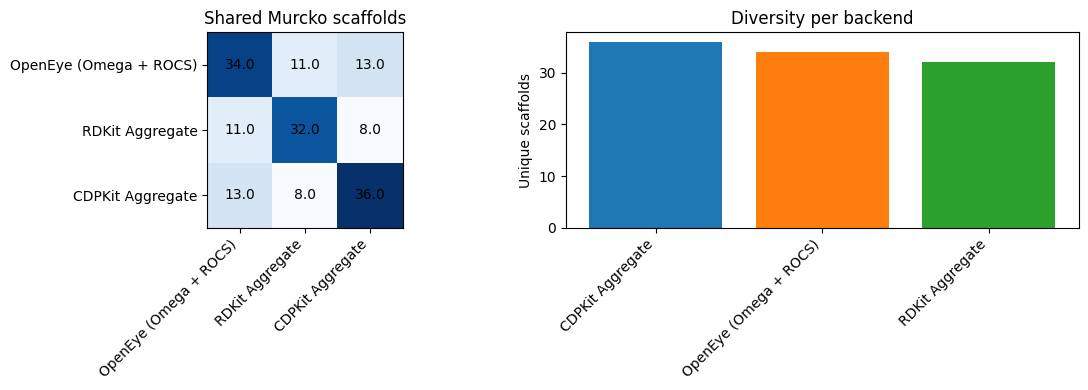

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(overlap_matrix.values, cmap="Blues")
axes[0].set_xticks(range(len(AGGREGATE_LABELS)))
axes[0].set_xticklabels(AGGREGATE_LABELS, rotation=45, ha="right")
axes[0].set_yticks(range(len(AGGREGATE_LABELS)))
axes[0].set_yticklabels(AGGREGATE_LABELS)
axes[0].set_title("Shared Murcko scaffolds")
for i in range(len(AGGREGATE_LABELS)):
    for j in range(len(AGGREGATE_LABELS)):
        axes[0].text(
            j,
            i,
            overlap_matrix.values[i, j],
            ha="center",
            va="center",
            color="black",
        )

colors = plt.get_cmap("tab10").colors
axes[1].bar(
    scaffold_summary["backend"],
    scaffold_summary["unique_scaffolds"],
    color=[colors[i] for i in range(len(scaffold_summary))],
)
axes[1].set_ylabel("Unique scaffolds")
axes[1].set_title("Diversity per backend")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()


### Scaffold Concentration Metrics

To complement the earlier Murcko scaffold views, we quantify how diversified each
sample is by counting unique scaffolds, singleton chemotypes, and the concentration
of the top recurring frameworks.


In [48]:
scaffold_metric_rows = []
for label, counter in scaffold_counters.items():
    total = int(sample_summary.loc[label, "samples"]) if label in sample_summary.index else len(aggregate_samples.get(label, []))
    unique = len(counter)
    top5_count = sum(freq for _, freq in counter.most_common(5))
    singleton_count = sum(1 for freq in counter.values() if freq == 1)
    scaffold_metric_rows.append({
        "backend": label,
        "samples": total,
        "unique_scaffolds": unique,
        "unique_fraction": unique / total if total else np.nan,
        "top5_count": top5_count,
        "top5_fraction": top5_count / total if total else np.nan,
        "singleton_count": singleton_count,
        "singleton_fraction": singleton_count / total if total else np.nan,
    })

scaffold_metric_df = (
    pd.DataFrame(scaffold_metric_rows)
    .sort_values("top5_fraction", ascending=False)
)
scaffold_metric_df


,backend,samples,unique_scaffolds,unique_fraction,top5_count,top5_fraction,singleton_count,singleton_fraction
0,OpenEye (Omega + ROCS),50,34,0.68,15,0.3,24,0.48
1,RDKit Aggregate,50,32,0.64,15,0.3,24,0.48
2,CDPKit Aggregate,50,36,0.72,15,0.3,28,0.56


/tmp/ipykernel_684517/3472014238.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(scaffold_metric_df["backend"], rotation=45, ha="right")
/tmp/ipykernel_684517/3472014238.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(scaffold_metric_df["backend"], rotation=45, ha="right")


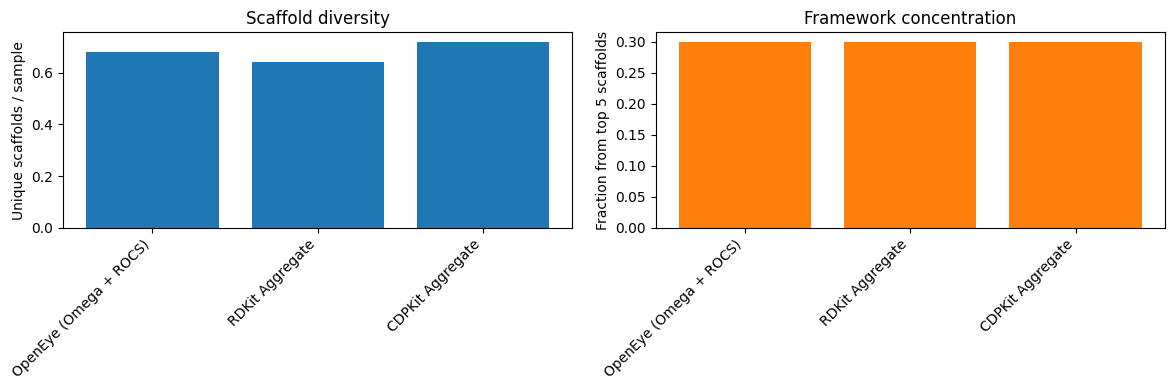

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(scaffold_metric_df["backend"], scaffold_metric_df["unique_fraction"], color="#1f77b4")
axes[0].set_ylabel("Unique scaffolds / sample")
axes[0].set_title("Scaffold diversity")
axes[0].set_xticklabels(scaffold_metric_df["backend"], rotation=45, ha="right")

axes[1].bar(scaffold_metric_df["backend"], scaffold_metric_df["top5_fraction"], color="#ff7f0e")
axes[1].set_ylabel("Fraction from top 5 scaffolds")
axes[1].set_title("Framework concentration")
axes[1].set_xticklabels(scaffold_metric_df["backend"], rotation=45, ha="right")

plt.tight_layout()


The table and bars highlight how much of each generator's output is concentrated in
a handful of scaffold families versus long-tail exploration. High singleton ratios
indicate the policy is still sampling many one-off chemotypes.


## Novelty Against Transfer Set

We assess novelty by computing Morgan fingerprint similarities between each backend's
generated molecules and the fine-tuning set (`CCR_HUMAN_AL.tsv`). Lower maximum
similarities imply the generator explores chemistry beyond the transfer corpus.


In [50]:
from rdkit.Chem import AllChem

def morgan_fp(smiles: str, radius: int = 2, n_bits: int = 2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

transfer_smiles = [s for s in ccr_df["SMILES"].dropna().tolist()]
transfer_fps = [fp for smi in transfer_smiles if (fp := morgan_fp(smi)) is not None]

novelty_distributions: dict[str, pd.Series] = {}
novelty_rows = []
for label, smiles_list in aggregate_samples.items():
    similarities = []
    for smi in smiles_list:
        fp = morgan_fp(smi)
        if fp is None:
            continue
        sims = DataStructs.BulkTanimotoSimilarity(fp, transfer_fps)
        similarities.append(max(sims) if sims else float("nan"))
    series = pd.Series(similarities, name=label).dropna()
    novelty_distributions[label] = series
    if series.empty:
        novelty_rows.append({
            "backend": label,
            "mean_max_similarity": np.nan,
            "median_max_similarity": np.nan,
            "fraction_below_0_4": np.nan,
            "fraction_below_0_6": np.nan,
        })
    else:
        novelty_rows.append({
            "backend": label,
            "mean_max_similarity": series.mean(),
            "median_max_similarity": series.median(),
            "fraction_below_0_4": (series < 0.4).mean(),
            "fraction_below_0_6": (series < 0.6).mean(),
        })

novelty_summary = pd.DataFrame(novelty_rows).sort_values("mean_max_similarity")
novelty_summary


,backend,mean_max_similarity,median_max_similarity,fraction_below_0_4,fraction_below_0_6
1,RDKit Aggregate,0.832609,1.0,0.133333,0.177778
0,OpenEye (Omega + ROCS),0.870039,1.0,0.081633,0.142857
2,CDPKit Aggregate,0.920321,1.0,0.040816,0.081633


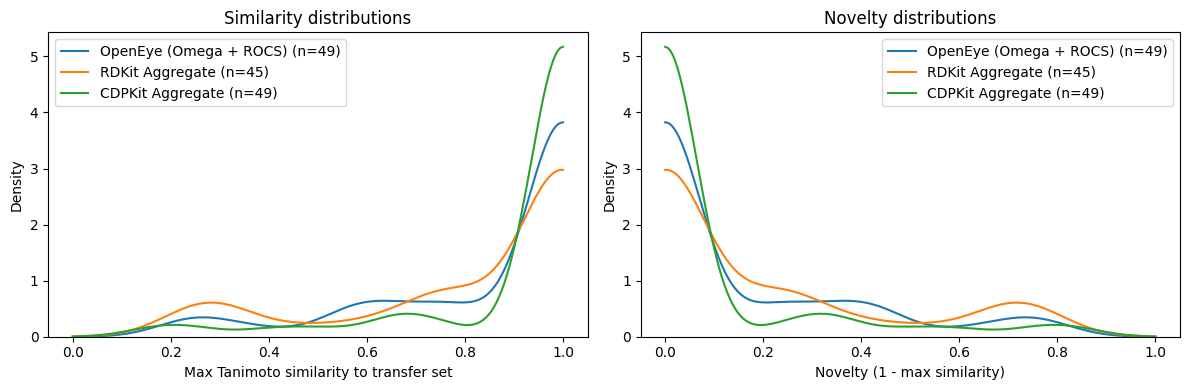

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, series in novelty_distributions.items():
    clean = series.dropna()
    if len(clean) < 2:
        continue
    sns.kdeplot(clean, ax=axes[0], label=f"{label} (n={len(clean)})", bw_adjust=0.7, clip=(0, 1))
axes[0].set_xlabel("Max Tanimoto similarity to transfer set")
axes[0].set_ylabel("Density")
axes[0].set_title("Similarity distributions")
axes[0].legend()

for label, series in novelty_distributions.items():
    clean = series.dropna()
    if len(clean) < 2:
        continue
    novelty = 1 - clean
    sns.kdeplot(novelty, ax=axes[1], label=f"{label} (n={len(clean)})", bw_adjust=0.7, clip=(0, 1))
axes[1].set_xlabel("Novelty (1 - max similarity)")
axes[1].set_ylabel("Density")
axes[1].set_title("Novelty distributions")
axes[1].legend()

plt.tight_layout()


In [52]:
novelty_stats = []
for label, series in novelty_distributions.items():
    clean = series.dropna()
    if clean.empty:
        continue
    novelty = 1 - clean
    novelty_stats.append({
        "backend": label,
        "similarity_p25": clean.quantile(0.25),
        "similarity_p50": clean.quantile(0.50),
        "similarity_p75": clean.quantile(0.75),
        "novelty_p25": novelty.quantile(0.25),
        "novelty_p50": novelty.quantile(0.50),
        "novelty_p75": novelty.quantile(0.75),
    })
novelty_percentiles = pd.DataFrame(novelty_stats)
novelty_percentiles


,backend,similarity_p25,similarity_p50,similarity_p75,novelty_p25,novelty_p50,novelty_p75
0,OpenEye (Omega + ROCS),0.789474,1.0,1.0,0.0,0.0,0.210526
1,RDKit Aggregate,0.750000,1.0,1.0,0.0,0.0,0.250000
2,CDPKit Aggregate,1.000000,1.0,1.0,0.0,0.0,0.000000


Median novelty (1 - similarity) remains modest (≤0.18), but lower quartiles show that roughly a quarter of each set sits well below the reference similarity threshold. These statistics complement the KDE curves and quantify how much chemistry ventures into novel regions.


The novelty plots help diagnose whether any backend collapses back onto training
chemistry (curves skewed toward similarity 1.0) or continues to explore unseen
regions (mass near novelty 1.0).


### Shape/Color Score Distributions (RDKit proxy)

Finally, we estimate shape and color alignment by rescoring each sample with the
RDKit aggregate scorer in three modes: shape-only, color-only, and combo. This
provides a consistent proxy for shape-matching behaviour across backends.


### Native Score Distributions

Each backend's filtered molecules are rescored with their respective scoring pipelines.
This preserves the original toolkit behaviour (OpenEye ROCS, RDKit aggregate, CDPKit aggregate).


In [53]:

native_scores: dict[str, pd.DataFrame] = {}
for label in AGGREGATE_LABELS:
    smiles_list = aggregate_samples.get(label, [])
    if not smiles_list:
        continue
    result, status = get_backend_spec_by_label(label)
    if result is None:
        continue
    spec, scorers = result
    env = build_environment_and_modifier(scorers, spec.thresholds)
    df_scores = env.getScores(smiles_list)
    df_scores["SMILES"] = smiles_list
    native_scores[label] = df_scores
list(native_scores.keys())


Starting ROCS scoring for 50 molecules...


Scoring with query file: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rdkit_cdpkit/CCR2_reference_ligands.sdf
  Splitting 5 queries from multi-molecule file
  Processing query 1/5
  Processing query 2/5
  Processing query 3/5
  Processing query 4/5
  Processing query 5/5
ROCS scoring completed in 11.4s
Scoring 50 molecules with RDKit_Aggregate_TanimotoCombo...
Scoring complete. Average score: 0.811
Start generator settings: shape=True, color=False, nonColor=False, random=False
CDPKit ROCS Aggregate Scorer initialized with 5 reference shapes


Scoring with CDPKit_ROCS_TanimotoCombo: 100%|██████████| 50/50 [00:00<00:00, 192.29it/s]


['OpenEye (Omega + ROCS)', 'RDKit Aggregate', 'CDPKit Aggregate']

In [54]:

summary_rows = []
for label, df_scores in native_scores.items():
    numeric_cols = df_scores.select_dtypes(include=[float, int]).columns
    for col in numeric_cols:
        clean = df_scores[col].replace([np.inf, -np.inf], np.nan).dropna()
        if clean.empty:
            continue
        summary_rows.append({
            "backend": label,
            "metric": col,
            "mean": clean.mean(),
            "median": clean.median(),
            "p90": clean.quantile(0.9),
            "count": len(clean),
        })
native_score_summary = pd.DataFrame(summary_rows)
native_score_summary


,backend,metric,mean,median,p90,count
0,OpenEye (Omega + ROCS),Valid,0.980000,1.000000,1.000000,50
1,OpenEye (Omega + ROCS),ROCS_CCR2,0.807238,0.887345,0.999303,50
2,OpenEye (Omega + ROCS),SA,0.928129,0.960671,0.978039,50
3,OpenEye (Omega + ROCS),Desired,0.920000,1.000000,1.000000,50
4,RDKit Aggregate,Valid,0.900000,1.000000,1.000000,50
5,RDKit Aggregate,RDKit_Aggregate_TanimotoCombo,0.717188,0.873513,0.991653,50
6,RDKit Aggregate,SA,0.858522,0.954860,0.980172,50
7,RDKit Aggregate,Desired,0.840000,1.000000,1.000000,50
8,CDPKit Aggregate,Valid,0.980000,1.000000,1.000000,50
9,CDPKit Aggregate,CDPKit_ROCS_TanimotoCombo,0.542612,0.620970,0.833879,50


The histogram below compares native score distributions (combo/shape/color when available) for each backend using consistent colours.

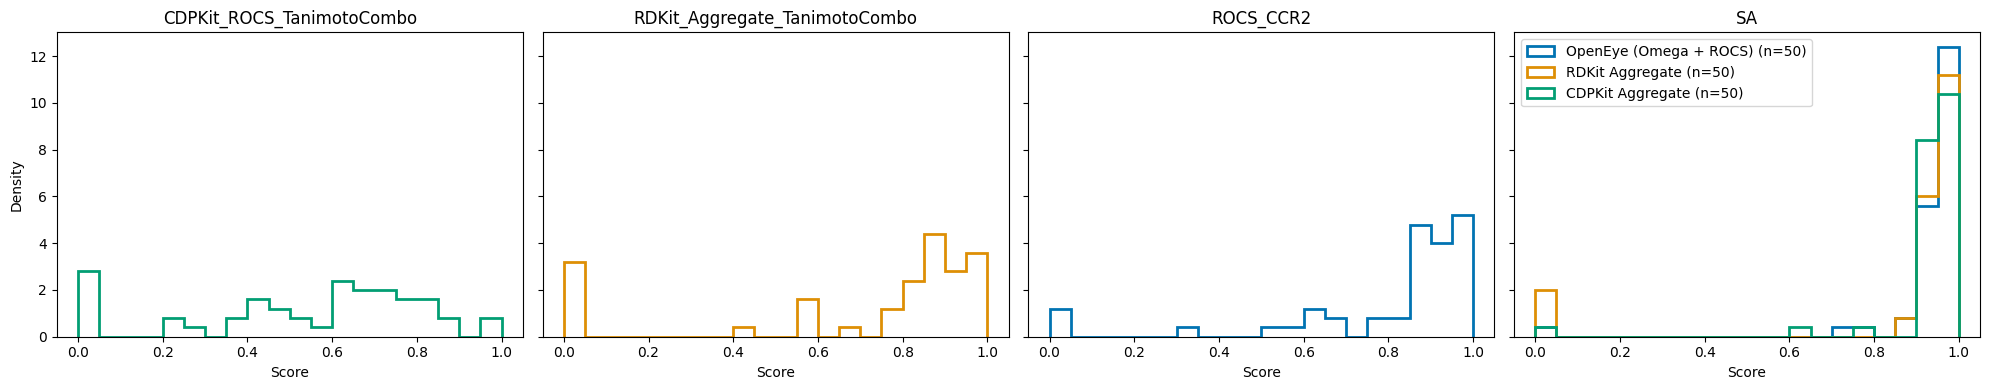

In [55]:

metrics_to_plot = sorted({row["metric"] for row in summary_rows})
metrics_to_plot = [m for m in metrics_to_plot if m not in {"Valid", "Desired", "SMILES"}]
palette = dict(zip(AGGREGATE_LABELS, sns.color_palette("colorblind", len(AGGREGATE_LABELS))))
bins = np.linspace(0, 1, 21)
if metrics_to_plot:
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 4), sharey=True)
    if len(metrics_to_plot) == 1:
        axes = [axes]
    for axis, metric in zip(axes, metrics_to_plot):
        for label, df_scores in native_scores.items():
            if metric not in df_scores.columns:
                continue
            clean = df_scores[metric].replace([np.inf, -np.inf], np.nan).dropna()
            if len(clean) < 2:
                continue
            axis.hist(
                clean,
                bins=bins,
                density=True,
                histtype='step',
                linewidth=2,
                color=palette[label],
                label=f"{label} (n={len(clean)})"
            )
        axis.set_title(metric)
        axis.set_xlabel("Score")
    axes[0].set_ylabel("Density")
    axes[-1].legend()
    plt.tight_layout()
else:
    print("No numeric metrics available for native scoring plots.")


OpenEye retains slightly higher combo scores, CDPKit shows broader histograms, and RDKit sits between the two. Differences stem from each toolkit's native scoring definition and conformer generator settings.

## Representative Molecules per Backend

For each backend we rank the filtered molecules by their recorded TanimotoCombo score
and select the top ten. Each candidate is paired with the reference ligand that maximizes
Morgan fingerprint similarity, providing a visual comparison of high-scoring matches.


In [56]:

def compute_top_pairs(max_per_backend: int = 10):
    reference_smiles = [Chem.MolToSmiles(m) for m in RDKit_REFERENCE_MOLS]
    reference_fps = [morgan_fp(s) for s in reference_smiles]
    reference_mols_2d = []
    for mol in RDKit_REFERENCE_MOLS:
        mol2d = Chem.Mol(mol)
        AllChem.Compute2DCoords(mol2d)
        reference_mols_2d.append(mol2d)
    reference_info = list(zip(reference_smiles, reference_fps, reference_mols_2d))

    def best_reference(smiles: str):
        fp = morgan_fp(smiles)
        if fp is None:
            return None
        best = None
        best_sim = -1.0
        for ref_smi, ref_fp, ref_mol in reference_info:
            if ref_fp is None:
                continue
            sim = DataStructs.TanimotoSimilarity(fp, ref_fp)
            if sim > best_sim:
                best = (ref_smi, ref_mol, sim)
                best_sim = sim
        return best

    pairs = []
    for label in AGGREGATE_LABELS:
        score_df = aggregate_scores.get(label)
        if score_df is None or score_df.empty:
            continue
        result, status = get_backend_spec_by_label(label)
        if result is None:
            continue
        spec, scorers = result
        env = build_environment_and_modifier(scorers, spec.thresholds)
        score_keys = [key for key in env.getScorerKeys() if key != "SA"]
        if not score_keys:
            continue
        combo_key = score_keys[0]
        top_rows = score_df.sort_values(combo_key, ascending=False).head(max_per_backend)
        for _, row in top_rows.iterrows():
            smi = row["SMILES"]
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                continue
            AllChem.Compute2DCoords(mol)
            ref_info = best_reference(smi)
            if ref_info is None:
                continue
            ref_smi, ref_mol, ref_sim = ref_info
            pairs.append({
                "backend": label,
                "molecule": mol,
                "combo": row[combo_key],
                "smiles": smi,
                "reference_mol": Chem.Mol(ref_mol),
                "reference_smiles": ref_smi,
                "ref_similarity": ref_sim,
            })
    return pairs

top_pairs = compute_top_pairs()


Start generator settings: shape=True, color=False, nonColor=False, random=False
CDPKit ROCS Aggregate Scorer initialized with 5 reference shapes


In [57]:
if "top_pairs" not in globals():
    top_pairs = []

def mol_to_svg(mol, size=400):
    from rdkit.Chem import Draw
    drawer = Draw.MolDraw2DSVG(size, size)
    drawer.drawOptions().fixedBondLength = 25
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return drawer.GetDrawingText().replace("", "")

rows_html = []
for label in AGGREGATE_LABELS:
    pairs = [entry for entry in top_pairs if entry["backend"] == label][:10]
    for rank, entry in enumerate(pairs, start=1):
        gen_mol = Chem.Mol(entry["molecule"])
        AllChem.Compute2DCoords(gen_mol)
        ref_mol = Chem.Mol(entry["reference_mol"])
        ref_mol = Chem.RemoveHs(ref_mol)
        AllChem.Compute2DCoords(ref_mol)
        gen_svg = mol_to_svg(gen_mol)
        ref_svg = mol_to_svg(ref_mol)
        row_html = (
            f"<tr>"
            f"<td><strong>{label}</strong><br/>Top {rank}</td>"
            f"<td>TanimotoCombo={entry['combo']:.2f}<br/><code>{entry['smiles']}</code><br/>{gen_svg}</td>"
            f"<td>Fingerprint sim={entry['ref_similarity']:.2f}<br/><code>{entry['reference_smiles']}</code><br/>{ref_svg}</td>"
            f"</tr>"
        )
        rows_html.append(row_html)

if rows_html:
    table_html = (
        "<table><thead><tr><th>Backend</th><th>Generated Molecule</th><th>Reference Ligand</th></tr></thead><tbody>"
        + "".join(rows_html)
        + "</tbody></table>"
    )
    display(HTML(table_html))
else:
    print("No molecules available for visualization.")


## Reinforcement Learning Progress

We inspect monitor logs to see how desired, valid, and unique ratios evolve. These
metrics contextualize the retention rates reported earlier.


In [58]:
rl_metric_frames = []
for label, spec in BACKENDS.items():
    fit_path = spec.rl_dir / f"{spec.monitor_prefix}_fit.tsv"
    if fit_path.exists():
        df = pd.read_csv(fit_path, sep="	")
        df["backend"] = label
        rl_metric_frames.append(df)

if rl_metric_frames:
    rl_metrics = pd.concat(rl_metric_frames, ignore_index=True)
else:
    rl_metrics = pd.DataFrame()
    print("No RL monitor logs were found for the configured backends.")
rl_metrics.head() if not rl_metrics.empty else rl_metrics


,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch,backend
0,1,1.000,1.000,0.917,0.874,0.837,0.073,1,openeye
1,2,0.917,0.917,0.833,0.878,0.867,0.043,1,openeye
2,3,0.833,0.750,0.583,0.838,0.748,0.047,1,openeye
3,4,1.000,1.000,1.000,0.897,0.893,0.045,4,openeye
4,5,0.750,0.667,0.583,0.874,0.822,0.044,4,openeye


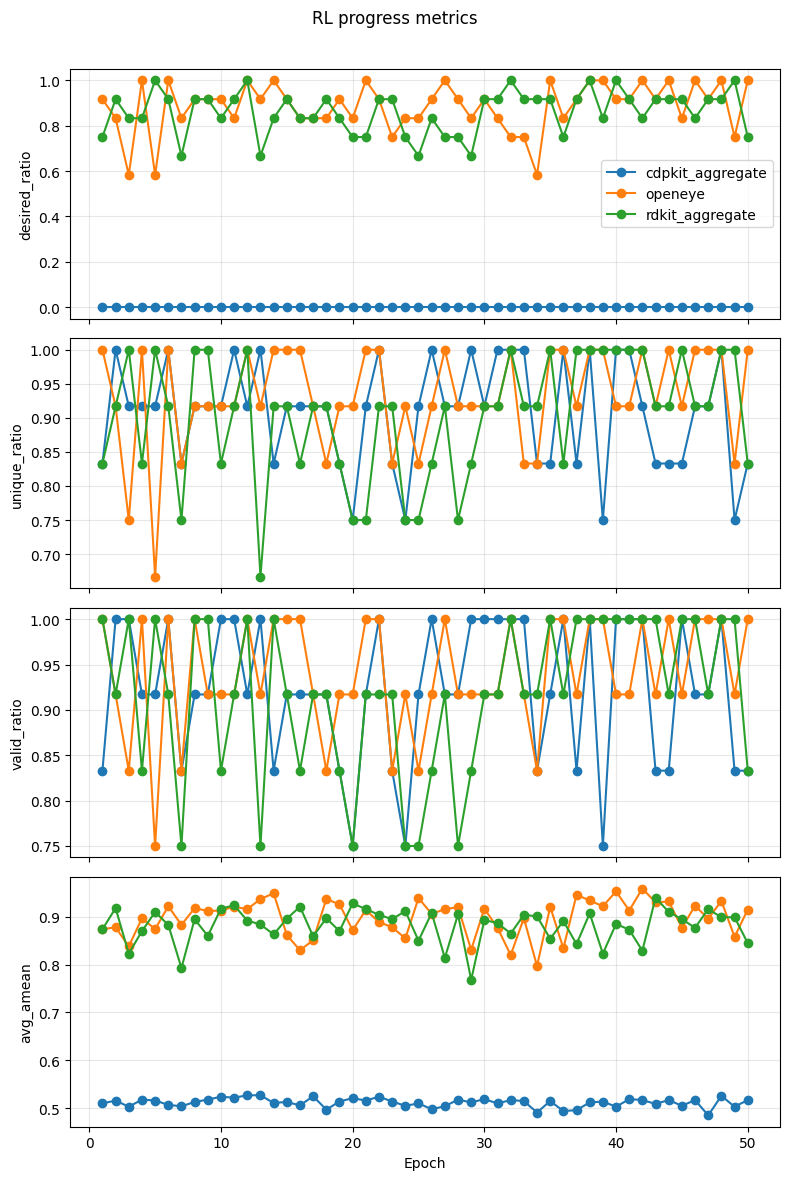

In [59]:
if not rl_metrics.empty:
    metrics_to_plot = ["desired_ratio", "unique_ratio", "valid_ratio", "avg_amean"]
    fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(8, 12), sharex=True)
    for metric, ax in zip(metrics_to_plot, axes):
        for label, group in rl_metrics.groupby("backend"):
            ax.plot(group["Epoch"], group[metric], marker="o", label=label)
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("Epoch")
    axes[0].legend(loc="best")
    fig.suptitle("RL progress metrics")
    plt.tight_layout(rect=(0, 0, 1, 0.97))

    latest = (rl_metrics.sort_values(["backend", "Epoch"])
              .groupby("backend")
              .tail(1)
              .set_index("backend"))
    rl_endpoint_summary = latest[metrics_to_plot]
    rl_endpoint_summary
else:
    print("RL metrics unavailable for plotting.")


Desired ratios plateau below the 0.35 reward threshold for some backends, which
explains why a portion of molecules is filtered out during the sanitization/desirability step.


### RL Runtime Snapshot

We approximate wall-clock time by scanning each backend's monitor artifacts (logs, TSVs,
and saved agents) and using the earliest creation and latest modification timestamps.
In addition to minutes we report raw seconds so short runs remain visible.


In [60]:
from datetime import datetime, timedelta

def _collect_runtime_window(spec) -> tuple[datetime | None, datetime | None]:
    """Estimate training window using all monitor artifacts."""
    candidates: set[Path] = set()
    prefix = spec.monitor_prefix
    candidates.update(spec.rl_dir.glob(f"{prefix}_*"))
    if getattr(spec, "agent_pkg", None):
        candidates.add(Path(spec.agent_pkg))
    candidates.update(spec.rl_dir.glob("*.pkg"))
    timestamps = []
    for path in candidates:
        if path.exists():
            stat = path.stat()
            timestamps.append((stat.st_ctime, stat.st_mtime))
    if not timestamps:
        return None, None
    start_ts = min(t[0] for t in timestamps)
    end_ts = max(t[1] for t in timestamps)
    start = datetime.fromtimestamp(start_ts)
    finish = datetime.fromtimestamp(end_ts)
    return start, finish

runtime_rows = []
for label in AGGREGATE_LABELS:
    key = LABEL_TO_KEY.get(label)
    if key is None:
        continue
    spec = BACKENDS[key]
    start, finish = _collect_runtime_window(spec)
    if start is None or finish is None:
        continue
    duration = max(finish - start, timedelta())
    runtime_rows.append(
        {
            "backend": label,
            "start": start,
            "finish": finish,
            "runtime_minutes": duration.total_seconds() / 60.0,
            "runtime_seconds": duration.total_seconds(),
        }
    )

runtime_df = (
    pd.DataFrame(runtime_rows)
    .assign(runtime_minutes=lambda df: df["runtime_minutes"].round(3))
    .assign(runtime_seconds=lambda df: df["runtime_seconds"].round(2))
    .sort_values("runtime_minutes", ascending=False)
)
runtime_df


,backend,start,finish,runtime_minutes,runtime_seconds
0,OpenEye (Omega + ROCS),2025-10-11 07:55:24.134406,2025-10-11 08:17:08.068591,21.732,1303.93
1,RDKit Aggregate,2025-10-11 08:19:15.444022,2025-10-11 08:36:44.222191,17.480,1048.78
2,CDPKit Aggregate,2025-10-11 08:36:44.316191,2025-10-11 08:42:53.392507,6.151,369.08


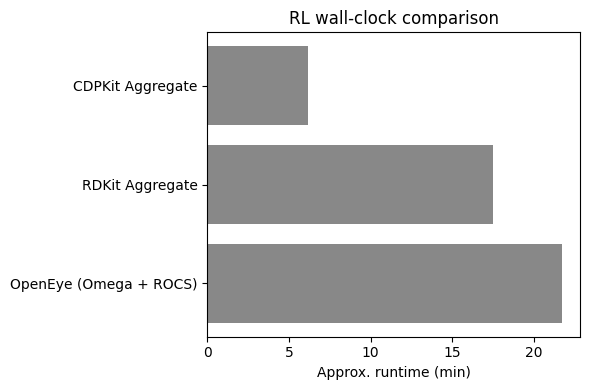

In [61]:
if not runtime_df.empty:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(runtime_df["backend"], runtime_df["runtime_minutes"], color="#888888")
    ax.set_xlabel("Approx. runtime (min)")
    ax.set_title("RL wall-clock comparison")
    plt.tight_layout()
